In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
RESULT_PATH = Path("../models/absa/test_results.json")

with open(RESULT_PATH, "r", encoding="utf-8") as f:
    results = json.load(f)

rows = []

for model_key, model_data in results.items():
    model_name = model_data["model_name"]
    dataset_version = model_data["dataset_version"]

    for aspect, aspect_data in model_data["aspect_results"].items():
        metrics = aspect_data["metrics"]

        rows.append({
            "model": model_name,
            "dataset_version": dataset_version,
            "aspect": aspect,
            "accuracy": metrics["accuracy"],
            "precision_macro": metrics["precision_macro"],
            "recall_macro": metrics["recall_macro"],
            "f1_macro": metrics["f1_macro"]
        })

df = pd.DataFrame(rows)
print(df.head())

    model dataset_version       aspect  accuracy  precision_macro  \
0  logreg              v1  description  0.855368         0.792586   
1  logreg              v1      quality  0.847382         0.775960   
2  logreg              v1    packaging  0.892635         0.721098   
3  logreg              v1     delivery  0.882875         0.738821   
4  logreg              v1      service  0.844720         0.720188   

   recall_macro  f1_macro  
0      0.792861  0.791982  
1      0.817058  0.793120  
2      0.732433  0.726033  
3      0.802226  0.764664  
4      0.761587  0.738833  


In [3]:
avg_f1 = df.groupby(["model", "dataset_version"])["f1_macro"].mean().reset_index()
print("\nAverage F1:")
print(avg_f1)


Average F1:
           model dataset_version  f1_macro
0            cnn              v1  0.755158
1            cnn              v2  0.743446
2            gru              v1  0.754870
3            gru              v2  0.747999
4         logreg              v1  0.764048
5         logreg              v2  0.769247
6        phobert              v1  0.836405
7        phobert              v2  0.847624
8  random_forest              v1  0.720317
9  random_forest              v2  0.720847


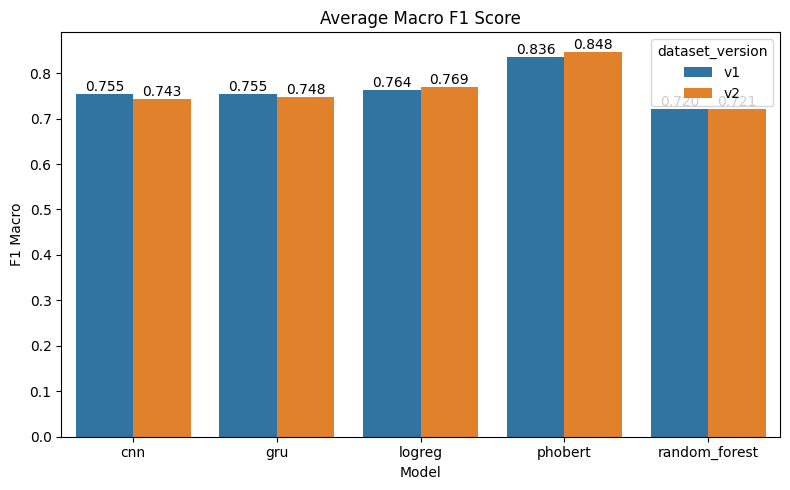

In [4]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=avg_f1, x="model", y="f1_macro", hue="dataset_version")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")
plt.title("Average Macro F1 Score")
plt.ylabel("F1 Macro")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

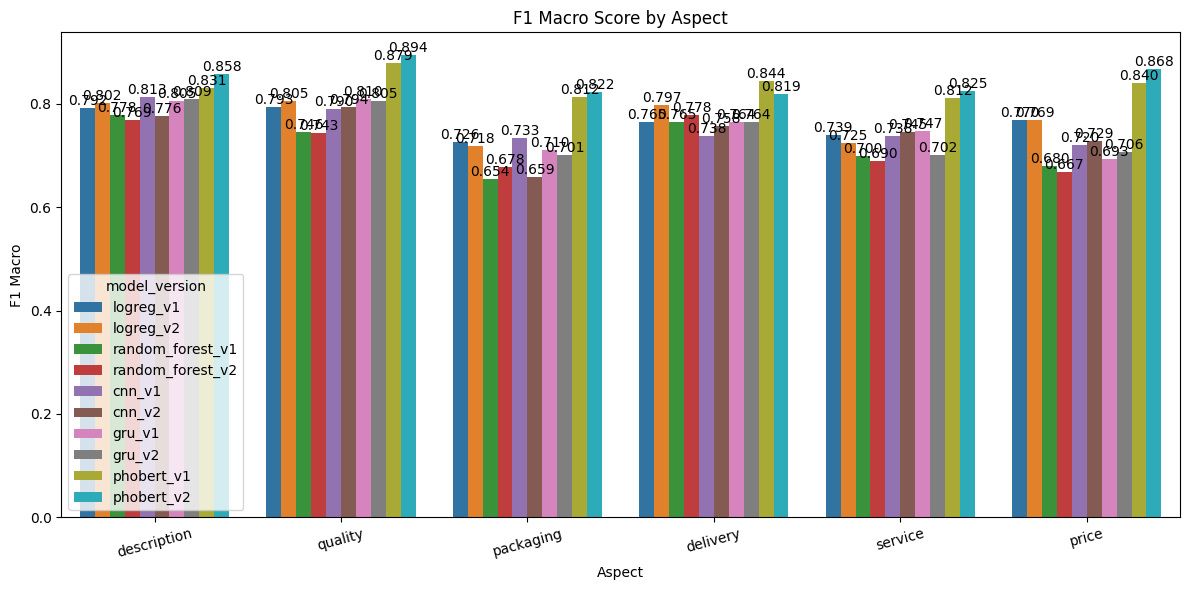

In [5]:
df["model_version"] = df["model"] + "_" + df["dataset_version"]
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df, x="aspect", y="f1_macro", hue="model_version")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")
plt.title("F1 Macro Score by Aspect")
plt.ylabel("F1 Macro")
plt.xlabel("Aspect")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

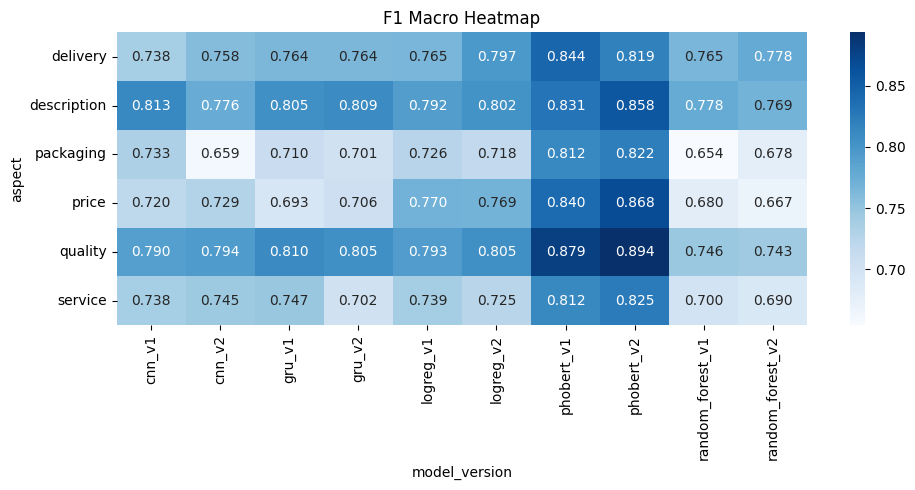

In [6]:
pivot_df = df.pivot_table(index="aspect", columns="model_version", values="f1_macro")
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_df, annot=True, fmt=".3f", cmap="Blues")
plt.title("F1 Macro Heatmap")
plt.tight_layout()
plt.show()

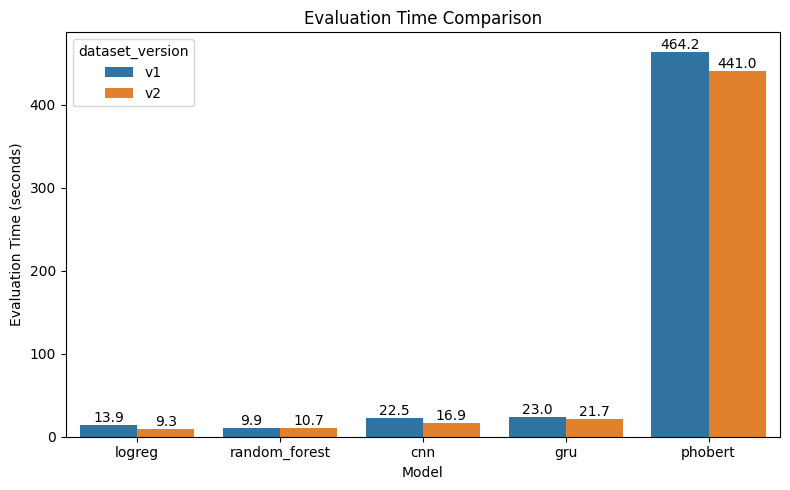

In [7]:
time_rows = []

for model_key, model_data in results.items():
    time_rows.append({
        "model": model_data["model_name"],
        "dataset_version": model_data["dataset_version"],
        "evaluation_time_seconds": model_data["evaluation_time_seconds"]
    })

time_df = pd.DataFrame(time_rows)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=time_df, x="model", y="evaluation_time_seconds", hue="dataset_version")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")
plt.title("Evaluation Time Comparison")
plt.ylabel("Evaluation Time (seconds)")
plt.xlabel("Model")
plt.tight_layout()
plt.show()